# Prophet Car Registrations Forecast
This notebook builds a Prophet model to forecast Malaysian monthly car registrations.
Same dataset and test split as `car_forecast_lstm.ipynb` (last 64 months = test).
Prophet works on the **original scale** of Car_Registrations — no manual differencing
needed, as Prophet models trend and seasonality natively.

Expected folder layout:
```
scraping/
    car_registrations.csv          ← produced by scraping.py
    car_forecast_lstm.ipynb
    car_forecast_prophet.ipynb     ← this notebook
    prophet_car_predictions.png    ← generated on run
```


## 1 — Import Required Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from itertools import product
from scipy.stats import zscore
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from prophet import Prophet

print('All libraries loaded successfully.')
print('If prophet is missing: pip install prophet')


All libraries loaded successfully.
If prophet is missing: pip install prophet


## 2 — Configuration
*Only edit this cell if the CSV path changes.*

In [5]:
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
CANDIDATE_PATHS = [
    NOTEBOOK_DIR / 'car_registrations.csv',
    NOTEBOOK_DIR / 'scraping' / 'car_registrations.csv',
    NOTEBOOK_DIR.parent / 'scraping' / 'car_registrations.csv',
    NOTEBOOK_DIR.parent.parent / 'scraping' / 'car_registrations.csv',
]

FILE_PATH = next((path for path in CANDIDATE_PATHS if path.exists()), None)
if FILE_PATH is None:
    raise FileNotFoundError(
        'Could not locate car_registrations.csv. Checked: '
        + ', '.join(str(path) for path in CANDIDATE_PATHS)
    )

TEST_SIZE    = 64   # matches LSTM split exactly

print(f'CSV found: {FILE_PATH}')


CSV found: d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\scraping\car_registrations.csv


## 3 — Load CSV Dataset

In [6]:
df = pd.read_csv(FILE_PATH)
df.columns = df.columns.str.strip().str.lower()
df = df.rename(columns={'date': 'Date', 'car_registration': 'Car_Registrations'})
if 'Date' not in df.columns or 'Car_Registrations' not in df.columns:
    raise KeyError(f'Expected columns Date and Car_Registrations, found: {list(df.columns)}')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print(f'Dataset shape before outlier removal: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'\nFirst 5 rows:')
print(df.head())
print(f'\nLast 5 rows:')
print(df.tail())


Dataset shape before outlier removal: (316, 2)
Columns: ['Date', 'Car_Registrations']

First 5 rows:
        Date  Car_Registrations
0 2000-01-01              26064
1 2000-02-01              23929
2 2000-03-01              32057
3 2000-04-01              29513
4 2000-05-01              31176

Last 5 rows:
          Date  Car_Registrations
311 2025-12-01              96970
312 2026-01-01              67995
313 2026-02-01              56690
314 2026-03-01              67846
315 2026-04-01              77869


## 4 — Outlier Smoothing (Z-Score, threshold = 3)
Identical to the LSTM notebook.
Any month with |Z-score| > 3 is replaced by NaN and linearly interpolated.


In [7]:
z_scores = np.abs(zscore(df['Car_Registrations']))
df['Car_Registrations'] = np.where(z_scores > 3, np.nan, df['Car_Registrations'])
df['Car_Registrations'] = df['Car_Registrations'].interpolate()

print(f'Date range: {df["Date"].min():%b %Y} to {df["Date"].max():%b %Y}')
print(f'Total months after outlier smoothing: {len(df)}')
print(f'Outliers smoothed: {(z_scores > 3).sum()}')


Date range: Jan 2000 to Apr 2026
Total months after outlier smoothing: 316
Outliers smoothed: 3


## 5 — Prepare Data for Prophet
Prophet requires `ds` (date) and `y` (target) columns.

**Note on log transformation:**
Unlike the LSTM/XGBoost pipelines which apply log + ADF differencing manually,
Prophet models the trend natively. We use the **log-transformed** Car_Registrations
as the `y` column — this stabilises variance and is consistent with the LSTM approach.
Predictions will be exponentiated back to original scale for fair metric comparison.

**No differencing is needed** — Prophet's piecewise linear trend handles non-stationarity.


In [8]:
# Use log-transformed values (consistent with LSTM variance stabilisation)
df_prophet = df[['Date', 'Car_Registrations']].copy()
df_prophet['log_y'] = np.log(df_prophet['Car_Registrations'])

prophet_df = df_prophet.rename(columns={'Date': 'ds', 'log_y': 'y'})

# Chronological 80/20-style split: last 64 months = test
split_idx = len(prophet_df) - TEST_SIZE
train_df  = prophet_df.iloc[:split_idx].copy().reset_index(drop=True)
test_df   = prophet_df.iloc[split_idx:].copy().reset_index(drop=True)

print(f'Train: {len(train_df)} rows  ({train_df["ds"].min():%b %Y} – {train_df["ds"].max():%b %Y})')
print(f'Test : {len(test_df)} rows   ({test_df["ds"].min():%b %Y} – {test_df["ds"].max():%b %Y})')
print('\ny column = log(Car_Registrations). Predictions will be exp() back to original scale.')


Train: 252 rows  (Jan 2000 – Dec 2020)
Test : 64 rows   (Jan 2021 – Apr 2026)

y column = log(Car_Registrations). Predictions will be exp() back to original scale.


## 6 — Hyperparameter Tuning (Walk-Forward Grid Search)
Mirrors the LSTM walk-forward structure: initial_train_size=120, val_size=12, 5 folds.
Grid searches over `changepoint_prior_scale`, `seasonality_prior_scale`,
and `seasonality_mode`.


In [9]:
param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.05, 0.1, 0.5],
    'seasonality_prior_scale': [1, 5, 10],
    'seasonality_mode'       : ['additive', 'multiplicative'],
}
INITIAL_TRAIN = 120
VAL_SIZE      = 12
N_SPLITS      = 5
n_combos      = (len(param_grid['changepoint_prior_scale'])
                 * len(param_grid['seasonality_prior_scale'])
                 * len(param_grid['seasonality_mode']))

print(f'Testing {n_combos} parameter combinations × {N_SPLITS} folds…')

best_rmse, best_params, all_results = float('inf'), {}, []

for cps, sps, smode in product(
        param_grid['changepoint_prior_scale'],
        param_grid['seasonality_prior_scale'],
        param_grid['seasonality_mode']):
    fold_rmses = []
    for split in range(N_SPLITS):
        train_end = INITIAL_TRAIN + (split + 1) * VAL_SIZE
        val_end   = train_end + VAL_SIZE
        if val_end > len(train_df):
            break
        cv_tr = train_df.iloc[:train_end].copy()
        cv_va = train_df.iloc[train_end:val_end].copy()
        try:
            m = Prophet(yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False,
                        changepoint_prior_scale=cps,
                        seasonality_prior_scale=sps,
                        seasonality_mode=smode)
            m.fit(cv_tr)
            fc   = m.predict(cv_va[['ds']])
            rmse = np.sqrt(mean_squared_error(cv_va['y'].values, fc['yhat'].values))
            fold_rmses.append(rmse)
        except Exception:
            pass
    if fold_rmses:
        avg_rmse = np.mean(fold_rmses)
        all_results.append({'cps': cps, 'sps': sps, 'mode': smode, 'rmse': avg_rmse})
        if avg_rmse < best_rmse:
            best_rmse   = avg_rmse
            best_params = {'changepoint_prior_scale': cps,
                           'seasonality_prior_scale': sps,
                           'seasonality_mode'       : smode}

print('\nTop 5 combinations (by average CV RMSE):')
print(pd.DataFrame(all_results).sort_values('rmse').head(5).to_string(index=False))
print('\nBest parameters:')
for k, v in best_params.items():
    print(f'  {k:<28}: {v}')
print(f'Best CV RMSE (log scale): {best_rmse:.6f}')


Testing 30 parameter combinations × 5 folds…


17:59:09 - cmdstanpy - INFO - Chain [1] start processing
17:59:09 - cmdstanpy - INFO - Chain [1] done processing
17:59:12 - cmdstanpy - INFO - Chain [1] start processing
17:59:12 - cmdstanpy - INFO - Chain [1] done processing
17:59:12 - cmdstanpy - INFO - Chain [1] start processing
17:59:12 - cmdstanpy - INFO - Chain [1] done processing
17:59:12 - cmdstanpy - INFO - Chain [1] start processing
17:59:12 - cmdstanpy - INFO - Chain [1] done processing
17:59:12 - cmdstanpy - INFO - Chain [1] start processing
17:59:12 - cmdstanpy - INFO - Chain [1] done processing
17:59:12 - cmdstanpy - INFO - Chain [1] start processing
17:59:12 - cmdstanpy - INFO - Chain [1] done processing
17:59:13 - cmdstanpy - INFO - Chain [1] start processing
17:59:13 - cmdstanpy - INFO - Chain [1] done processing
17:59:13 - cmdstanpy - INFO - Chain [1] start processing
17:59:13 - cmdstanpy - INFO - Chain [1] done processing
17:59:13 - cmdstanpy - INFO - Chain [1] start processing
17:59:13 - cmdstanpy - INFO - Chain [1]


Top 5 combinations (by average CV RMSE):
 cps  sps           mode     rmse
0.01   10       additive 0.107438
0.01   10 multiplicative 0.107678
0.01    1       additive 0.107740
0.01    5       additive 0.107793
0.01    5 multiplicative 0.108575

Best parameters:
  changepoint_prior_scale     : 0.01
  seasonality_prior_scale     : 10
  seasonality_mode            : additive
Best CV RMSE (log scale): 0.107438


## 7 — Train Final Prophet Model on Full Training Set

In [10]:
model = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = False,   # monthly data — not applicable
    daily_seasonality  = False,   # monthly data — not applicable
    interval_width     = 0.95,    # 95% uncertainty interval
    **best_params
)
model.fit(train_df)

print('Prophet model trained successfully.')
for k, v in best_params.items():
    print(f'  {k:<28}: {v}')


17:59:43 - cmdstanpy - INFO - Chain [1] start processing
17:59:44 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.
  changepoint_prior_scale     : 0.01
  seasonality_prior_scale     : 10
  seasonality_mode            : additive


## 7b — Save Model File
The trained Prophet model is serialised with `pickle` and saved as `prophet_model.pkl`.
Reload it later with `pickle.load(open('prophet_model.pkl', 'rb'))`.

In [11]:
import pickle
from pathlib import Path

MODEL_PATH = Path.cwd() / 'prophet_model.pkl'
with open(MODEL_PATH, 'wb') as fh:
    pickle.dump(model, fh)
print(f'Model saved: {MODEL_PATH}')
print(f'File size  : {MODEL_PATH.stat().st_size / 1024:.1f} KB')

Model saved: d:\Year 3 Sem 1\COS40007 AI Engineering\Assignment\Prophet\car_forecast_prophet\prophet_model.pkl
File size  : 32.8 KB


## 8 — Generate Predictions

In [12]:
tr_fc = model.predict(train_df[['ds']])
te_fc = model.predict(test_df[['ds']])

# Log-scale predictions
y_pred_log_tr = tr_fc['yhat'].values
y_pred_log_te = te_fc['yhat'].values
y_lower_log   = te_fc['yhat_lower'].values
y_upper_log   = te_fc['yhat_upper'].values
y_act_log_tr  = train_df['y'].values
y_act_log_te  = test_df['y'].values

# Exp back to original car registration counts
y_pred_original_tr = np.exp(y_pred_log_tr)
y_pred_original    = np.exp(y_pred_log_te)
y_lower_original   = np.exp(y_lower_log)
y_upper_original   = np.exp(y_upper_log)
y_act_original_tr  = np.exp(y_act_log_tr)
y_act_original     = np.exp(y_act_log_te)

print(f'Train predictions shape: {y_pred_original_tr.shape}')
print(f'Test  predictions shape: {y_pred_original.shape}')


Train predictions shape: (252,)
Test  predictions shape: (64,)


## 9 — Evaluate with MSE, RMSE, and R²
Metrics reported on both **scaled (log) data** and **original scale** —
identical structure to LSTM Cell 21 and Cell 23.


In [13]:
# Metrics on log scale (= scaled data equivalent for Prophet)
mse_scaled  = mean_squared_error(y_act_log_te, y_pred_log_te)
rmse_scaled = np.sqrt(mse_scaled)
r2_scaled   = r2_score(y_act_log_te, y_pred_log_te)

# Metrics on original scale
mse_original  = mean_squared_error(y_act_original, y_pred_original)
rmse_original = np.sqrt(mse_original)
r2_original   = r2_score(y_act_original, y_pred_original)
mae_original  = mean_absolute_error(y_act_original, y_pred_original)

print('=== Metrics on Scaled (Log) Data ===')
print(f'MSE (scaled):  {mse_scaled:.6f}')
print(f'RMSE (scaled): {rmse_scaled:.6f}')
print(f'R² (scaled):   {r2_scaled:.6f}')

print('\n=== Metrics on Original Scale ===')
print(f'MSE (original):  {mse_original:.2f}')
print(f'RMSE (original): {rmse_original:.2f}')
print(f'MAE (original):  {mae_original:.2f}')
print(f'R² (original):   {r2_original:.6f}')


=== Metrics on Scaled (Log) Data ===
MSE (scaled):  0.242747
RMSE (scaled): 0.492694
R² (scaled):   -0.931814

=== Metrics on Original Scale ===
MSE (original):  605095775.21
RMSE (original): 24598.69
MAE (original):  22495.91
R² (original):   -1.841668


## 10 — Plot Prediction vs Actual
All plots combined into **one figure** → `prophet_car_predictions.png`.


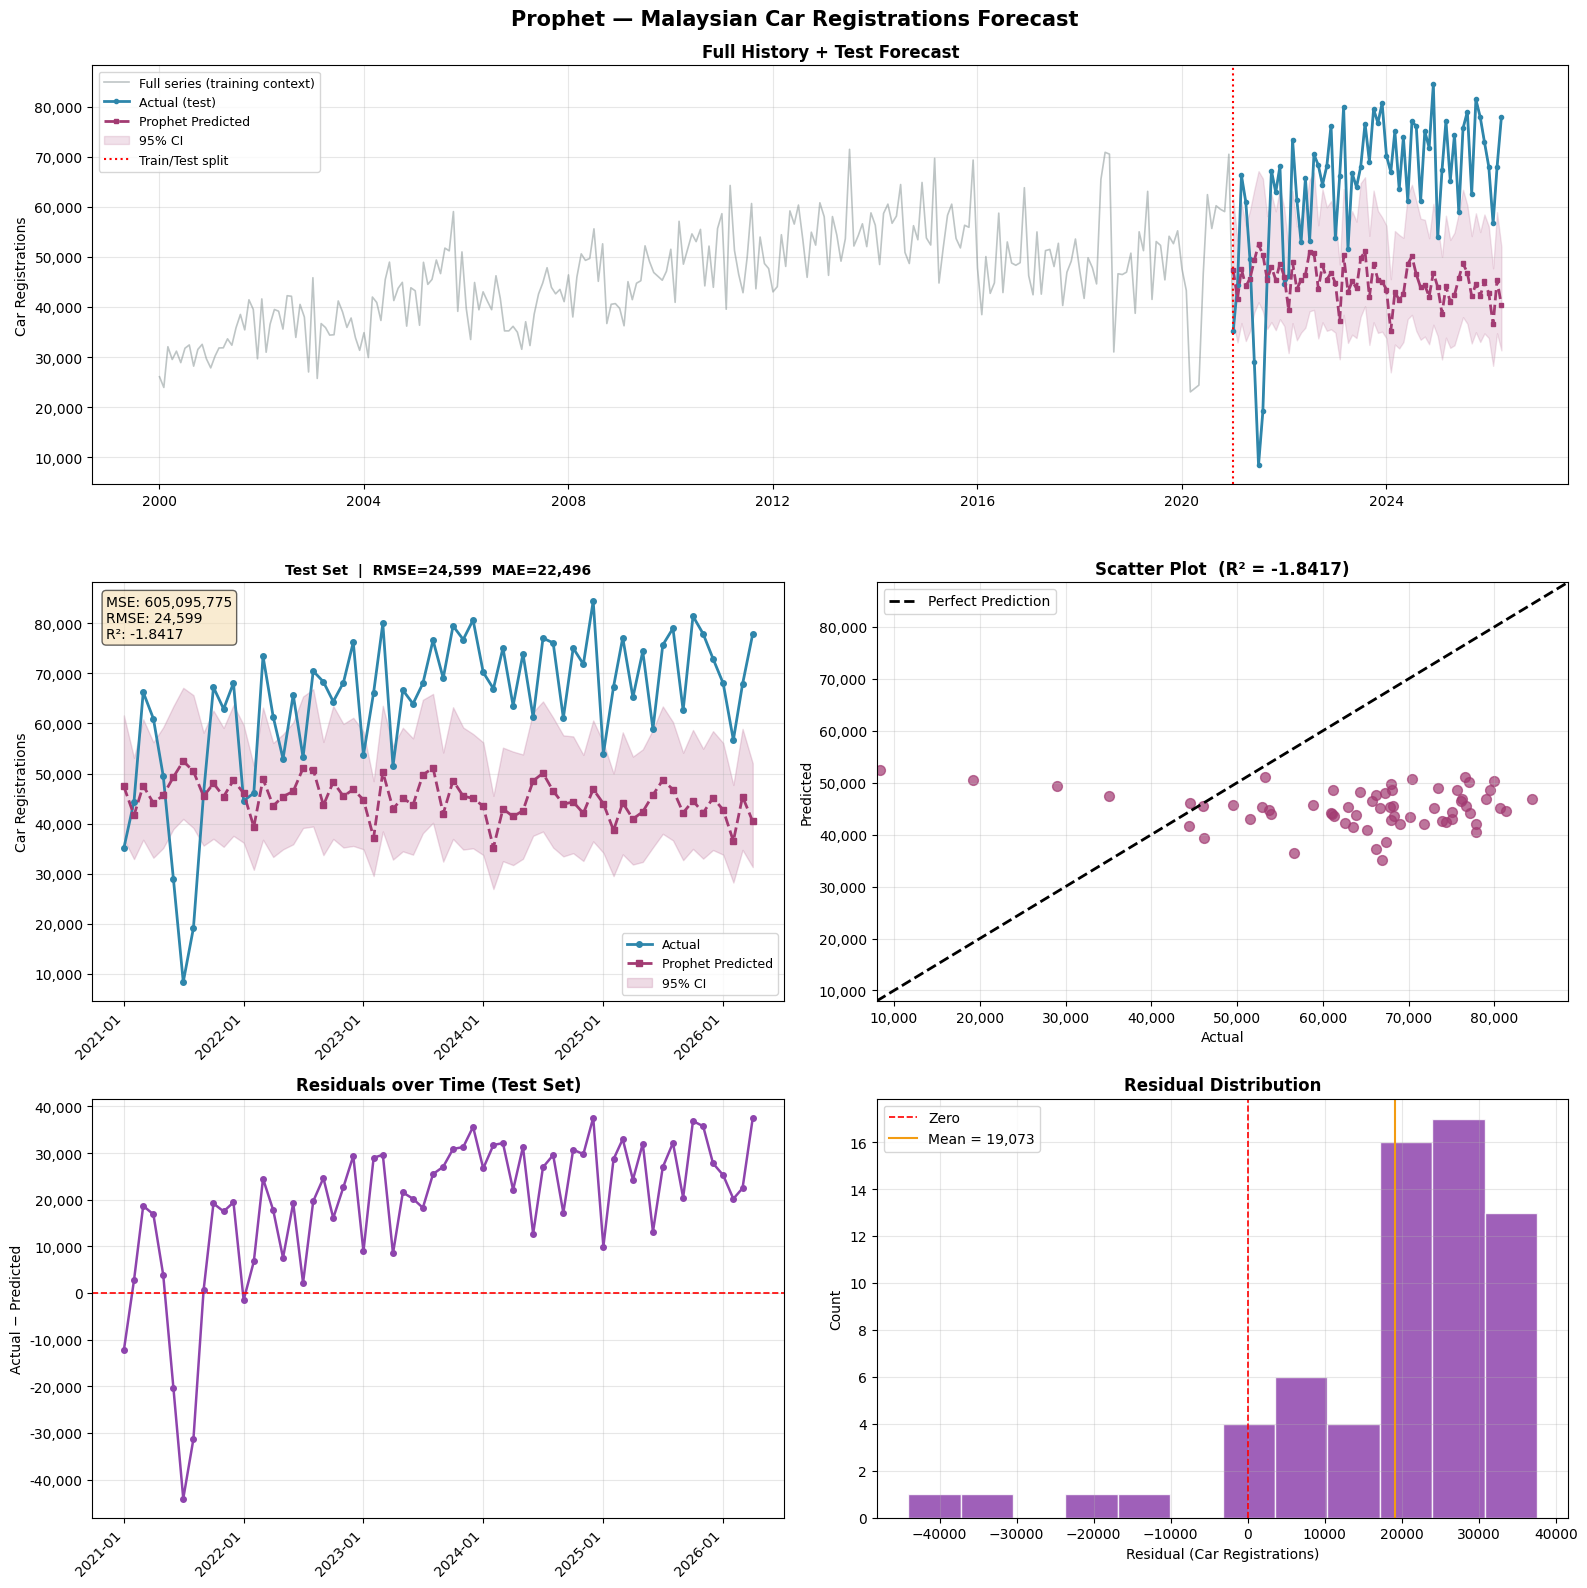


✓ Prophet forecast completed successfully!
Saved: prophet_car_predictions.png


In [14]:
train_dates = train_df['ds'].values
test_dates  = test_df['ds'].values
full_fc     = model.predict(prophet_df[['ds']])
residuals   = y_act_original - y_pred_original

fig = plt.figure(figsize=(16, 16))
fig.suptitle('Prophet — Malaysian Car Registrations Forecast', fontsize=15,
             fontweight='bold', y=0.99)

# ① Full series context
ax0 = fig.add_subplot(3, 2, (1, 2))
ax0.plot(df['Date'], df['Car_Registrations'], color='#7f8c8d', lw=1.2,
         alpha=0.5, label='Full series (training context)')
ax0.plot(test_dates, y_act_original,
         color='#2E86AB', lw=2, marker='o', ms=3, label='Actual (test)')
ax0.plot(test_dates, y_pred_original,
         color='#A23B72', lw=2, ls='--', marker='s', ms=3, label='Prophet Predicted')
ax0.fill_between(test_dates, y_lower_original, y_upper_original,
                 alpha=0.15, color='#A23B72', label='95% CI')
ax0.axvline(pd.Timestamp(test_dates[0]), color='red', ls=':', lw=1.5,
            label='Train/Test split')
ax0.set_title('Full History + Test Forecast', fontweight='bold')
ax0.set_ylabel('Car Registrations')
ax0.legend(fontsize=9); ax0.grid(alpha=0.3)
ax0.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ② Test set: Actual vs Predicted
ax1 = fig.add_subplot(3, 2, 3)
ax1.plot(test_dates, y_act_original,
         color='#2E86AB', lw=2, marker='o', ms=4, label='Actual')
ax1.plot(test_dates, y_pred_original,
         color='#A23B72', lw=2, ls='--', marker='s', ms=4, label='Prophet Predicted')
ax1.fill_between(test_dates, y_lower_original, y_upper_original,
                 alpha=0.18, color='#A23B72', label='95% CI')
ax1.set_title(f'Test Set  |  RMSE={rmse_original:,.0f}  MAE={mae_original:,.0f}',
              fontweight='bold', fontsize=10)
ax1.set_ylabel('Car Registrations')
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
metrics_text = (f'MSE: {mse_original:,.0f}\n'
                f'RMSE: {rmse_original:,.0f}\n'
                f'R²: {r2_original:.4f}')
ax1.text(0.02, 0.97, metrics_text, transform=ax1.transAxes,
         fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# ③ Scatter
ax2 = fig.add_subplot(3, 2, 4)
ax2.scatter(y_act_original, y_pred_original, alpha=0.7, s=50, color='#A23B72')
lim = [min(y_act_original.min(), y_pred_original.min()) * 0.95,
       max(y_act_original.max(), y_pred_original.max()) * 1.05]
ax2.plot(lim, lim, 'k--', lw=2, label='Perfect Prediction')
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_title(f'Scatter Plot  (R² = {r2_original:.4f})', fontweight='bold')
ax2.set_xlabel('Actual'); ax2.set_ylabel('Predicted')
ax2.legend(); ax2.grid(alpha=0.3)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ④ Residuals over time
ax3 = fig.add_subplot(3, 2, 5)
ax3.plot(test_dates, residuals, color='#8e44ad', lw=1.8, marker='o', ms=4)
ax3.axhline(0, color='red', ls='--', lw=1.2)
ax3.set_title('Residuals over Time (Test Set)', fontweight='bold')
ax3.set_ylabel('Actual − Predicted')
ax3.grid(alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# ⑤ Residual distribution
ax4 = fig.add_subplot(3, 2, 6)
ax4.hist(residuals, bins=12, color='#8e44ad', edgecolor='white', alpha=0.85)
ax4.axvline(0, color='red', ls='--', lw=1.2, label='Zero')
ax4.axvline(residuals.mean(), color='#f39c12', lw=1.5,
            label=f'Mean = {residuals.mean():,.0f}')
ax4.set_title('Residual Distribution', fontweight='bold')
ax4.set_xlabel('Residual (Car Registrations)'); ax4.set_ylabel('Count')
ax4.legend(); ax4.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prophet_car_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✓ Prophet forecast completed successfully!')
print(f'Saved: prophet_car_predictions.png')


### Component Decomposition *(stays inside notebook only)*
Prophet's unique feature: trend, yearly seasonality, and any holiday effects
are shown separately — directly interpretable for policy insight.


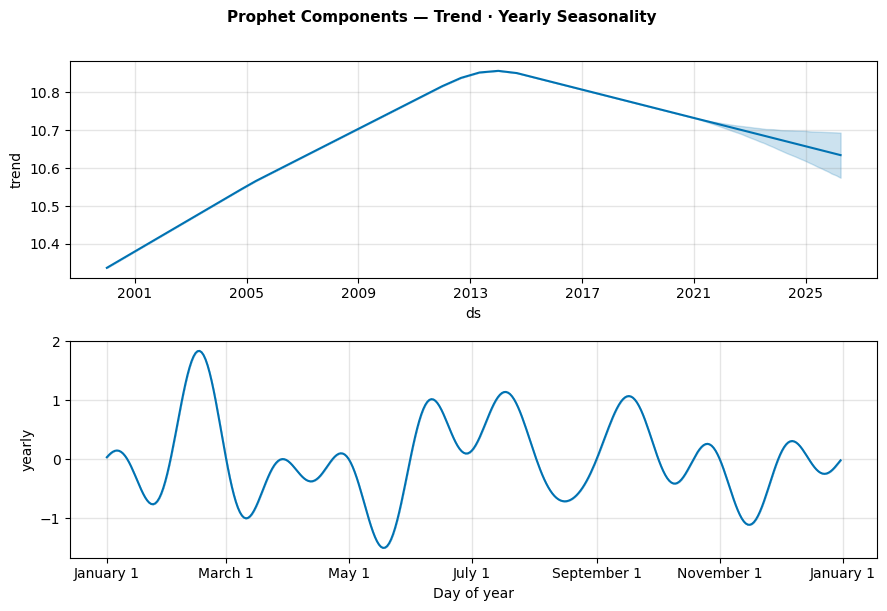

In [15]:
fig_comp = model.plot_components(full_fc)
fig_comp.suptitle('Prophet Components — Trend · Yearly Seasonality',
                  fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
# No savefig — stays inside the notebook only


## 11 — Results Summary

In [16]:
print('='*55)
print('  PROPHET CAR REGISTRATIONS — FINAL RESULTS')
print('='*55)
print(f'  MSE  (original) : {mse_original:>15,.2f}')
print(f'  RMSE (original) : {rmse_original:>15,.2f}')
print(f'  MAE  (original) : {mae_original:>15,.2f}')
print(f'  R²   (original) : {r2_original:>15.6f}')
print('-'*55)
print(f'  MSE  (log scale): {mse_scaled:>15.6f}')
print(f'  RMSE (log scale): {rmse_scaled:>15.6f}')
print(f'  R²   (log scale): {r2_scaled:>15.6f}')
print('='*55)
print(f'  Test period: {test_df["ds"].min():%b %Y} – {test_df["ds"].max():%b %Y}')
print('\n  Best hyperparameters:')
for k, v in best_params.items():
    print(f'    {k:<28}: {v}')


  PROPHET CAR REGISTRATIONS — FINAL RESULTS
  MSE  (original) :  605,095,775.21
  RMSE (original) :       24,598.69
  MAE  (original) :       22,495.91
  R²   (original) :       -1.841668
-------------------------------------------------------
  MSE  (log scale):        0.242747
  RMSE (log scale):        0.492694
  R²   (log scale):       -0.931814
  Test period: Jan 2021 – Apr 2026

  Best hyperparameters:
    changepoint_prior_scale     : 0.01
    seasonality_prior_scale     : 10
    seasonality_mode            : additive


---
## 12 — Methodology Notes *(for Report)*

### Pipeline Alignment with LSTM
Z-score outlier smoothing (threshold=3) is applied identically to the LSTM notebook.
The same 64-month test period (Jan 2021 – Apr 2026) is used. Log transformation
is applied to `y` for variance stabilisation, consistent with the LSTM approach.
Metrics are reported on both log scale (comparable to the LSTM's scaled metrics)
and original car registration scale.

### Why No Differencing for Prophet?
The LSTM applies first-order differencing because it uses a MinMaxScaler + lag
approach where stationarity improves training. Prophet models trend natively via
piecewise linear growth with automatically detected changepoints — it does not
require the series to be stationary. Applying differencing to Prophet would remove
the trend information that Prophet is specifically designed to model.

### Hyperparameter Tuning
Walk-forward grid search with 5 folds (initial_train_size=120, val_size=12) mirrors
the LSTM validation structure. `changepoint_prior_scale` is the most impactful
parameter — it controls how flexibly the trend adapts to structural breaks such as
the COVID lockdown recovery surge visible in 2021–2022.

### Uncertainty Intervals
Prophet generates 95% posterior uncertainty intervals via Stan MCMC sampling.
These are shown on the forecast plots and are particularly valuable for the
post-COVID recovery period where structural uncertainty is high.

### Seasonality
Only yearly seasonality is enabled. Weekly and daily seasonality are disabled —
monthly data cannot identify those cycles and their inclusion would add noise.
The yearly component captures the consistent pattern of registration dips in Q1
(Chinese New Year, school-year start) and peaks in Q4.

### Limitation
The 2021–2026 test period contains the COVID recovery surge — a structural break
that no model trained purely on pre-2021 data can fully anticipate. This affects
all three models (LSTM, XGBoost, Prophet) equally and should be acknowledged
as a dataset limitation rather than a modelling failure.
